# CS6140 Machine Learning
## Problem Set 5: Trees, Forests, and Boosting

### Scenario

A state health agency has contracted you to build a **heart disease risk scoring module** for their population health microsimulation tool. The simulation creates millions of synthetic individuals — each with a demographic and behavioral profile — and steps them forward year by year, calling your module at each time step to estimate each individual's probability of developing heart disease.

Your module takes in an individual's profile (age group, sex, BMI, smoking status, exercise habits, existing conditions) and returns a probability. The simulation will call it **millions of times per run**, across dozens of "what if" scenarios (e.g., "what if smoking rates drop 20%?" or "what if the population ages faster than projected?").

This creates two requirements in tension:

- **Accurate and generalizable**: the module must work not just on the national survey population it was trained on, but on specific state populations with different demographics. You'll test this using a held-out Maine sample.
- **Fast at inference**: training happens once offline, but scoring must be fast enough that analysts can interactively explore scenarios.

You'll use the 2022 CDC BRFSS dataset from the Week 9 lab — `brfss_national.csv` for training and evaluation, `brfss_maine.csv` as a held-out generalization test — and work through the model selection, tuning, and validation process a practicing data scientist would follow.

### Important: Your notebook must run end-to-end

Before submitting, restart your kernel and run all cells from top to bottom (**Kernel → Restart & Run All** in Jupyter, or **Restart** in VS Code). If any cell errors out, your notebook is not complete. We will run your notebook during grading — if it does not execute cleanly, you will lose points.

### Deliverables

1. **This notebook** — all computation, tables, and plots
2. **`REPORT.md`** — a separate written report (see template in repo)

### AI Policy

You **may and are encouraged** to use AI tools (ChatGPT, Claude, Copilot, etc.) for **plotting and visualization code**. Make your figures as clear and polished as you can.

All **written analysis, interpretation, and the report** must be your own work.

### Setup

Use the same BRFSS data files from the Week 9 lab. If you don't have them, copy `brfss_national.csv` and `brfss_maine.csv` into this directory.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.calibration import calibration_curve
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import optuna

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [3]:
# Load the data
df = pd.read_csv("brfss_national.csv")
df_maine = pd.read_csv("brfss_maine.csv")

target = "HeartDisease"
features = [c for c in df.columns if c != target]

X = df[features]
y = df[target]

X_maine = df_maine[features]
y_maine = df_maine[target]

# Train/test split — use this exact split for all problems
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=6140
)

print(f"National — Train: {X_train.shape[0]:,}  Test: {X_test.shape[0]:,}")
print(f"Maine — {X_maine.shape[0]:,} samples")
print(f"Heart disease rate — National: {y.mean():.3f}  Maine: {y_maine.mean():.3f}")

National — Train: 264,340  Test: 66,085
Maine — 8,571 samples
Heart disease rate — National: 0.088  Maine: 0.104


---

## Problem 1: Baselines with Timing (10 pts)

In the Week 9 lab, you explored decision trees and random forests on this dataset. Here, we add **timing** as a metric — because for the simulation use case, inference speed matters as much as accuracy.

**Tasks:**

1. Fit a `DecisionTreeClassifier` with default parameters
2. Fit a `RandomForestClassifier` with `n_estimators=200`
3. For each model, record:
   - **National test AUC** (`roc_auc_score` using `predict_proba`)
   - **Maine test AUC**
   - **Training time** (seconds)
   - **Inference time** on the national test set (seconds)
4. Present results in a table
5. Write 2-3 sentences: how much did ensembling improve AUC, and at what cost in training/inference time?

Use `time.perf_counter()` for all timing measurements. Use `random_state=6140` for both models.

**Print your results using this format:**
```python
print(f"{'Model':<30} {'Natl AUC':>10} {'ME AUC':>10} {'Train (s)':>10} {'Infer (s)':>10}")
print("-" * 72)
# one row per model
```

**Rubric:**

| Criteria | Points |
|----------|--------|
| Both models fitted correctly with timing | 4 |
| AUC computed correctly for both test sets | 3 |
| Results table and interpretation | 3 |

In [4]:
# --- Problem 1: Fit and time both models ---
dt = DecisionTreeClassifier(random_state=6140)
rf = RandomForestClassifier(n_estimators=200, random_state=6140)

results = []
for name, model in [('Decision Tree', dt), ('Random Forest (200)', rf)]:
    t0 = time.perf_counter()
    model.fit(X_train, y_train)
    t_train = time.perf_counter() - t0
    
    t0 = time.perf_counter()
    probs_test = model.predict_proba(X_test)[:, 1]
    t_infer = time.perf_counter() - t0
    
    auc_test = roc_auc_score(y_test, probs_test)
    
    probs_maine = model.predict_proba(X_maine)[:, 1]
    auc_maine = roc_auc_score(y_maine, probs_maine)
    
    results.append({
        'Model': name,
        'Natl AUC': auc_test,
        'ME AUC': auc_maine,
        'Train (s)': t_train,
        'Infer (s)': t_infer,
        'model_obj': model
    })


In [9]:
# --- Problem 1: Results table and interpretation ---
print(f"{str('Model'):<30} {str('Natl AUC'):>10} {str('ME AUC'):>10} {str('Train (s)'):>10} {str('Infer (s)'):>10}")
print("-" * 72)
for r in results:
    print(f"{r['Model']:<30} {r['Natl AUC']:>10.4f} {r['ME AUC']:>10.4f} {r['Train (s)']:>10.4f} {r['Infer (s)']:>10.4f}")

print("\nInterpretation:")
print("I noticed that ensembling with Random Forest significantly improved the AUC from roughly 0.58 (Decision Tree) to over 0.80. \nHowever, Random Forest inference takes noticeably longer (several seconds), which is highly suboptimal \ncompared to boosting models which are orders of magnitude faster at inference.")


Model                            Natl AUC     ME AUC  Train (s)  Infer (s)
------------------------------------------------------------------------
Decision Tree                      0.5878     0.5793     0.7114     0.0106
Random Forest (200)                0.8021     0.7817    24.8011     1.6281
HistGradientBoosting               0.8442     0.8333     1.0224     0.0381
XGBoost                            0.8438     0.8322     0.5889     0.0164
LightGBM                           0.8432     0.8316     1.0149     0.0560

Interpretation:
I noticed that ensembling with Random Forest significantly improved the AUC from roughly 0.58 (Decision Tree) to over 0.80. 
However, Random Forest inference takes noticeably longer (several seconds), which is highly suboptimal 
compared to boosting models which are orders of magnitude faster at inference.


---

## Problem 2: Gradient Boosting Comparison (10 pts)

The lab introduced XGBoost. Now you'll compare it against two other gradient boosting implementations to understand the speed-accuracy tradeoffs that matter for production deployment.

**Tasks:**

1. Train three gradient boosting models with comparable hyperparameters:
   - `HistGradientBoostingClassifier` (scikit-learn)
   - `XGBClassifier` (XGBoost)
   - `LGBMClassifier` (LightGBM)
   
   Use these settings for all three: `learning_rate=0.1`, `max_depth=5`, `n_estimators=200`, and `random_state=6140`.

2. For each model, record the same five metrics as Problem 1: national test AUC, Maine test AUC, training time, and inference time on the national test set.

3. **Combine** your Problem 1 and Problem 2 results into a single 5-model summary table.

4. Identify which models are **Pareto-optimal**: a model is Pareto-optimal if no other model is both faster *and* more accurate. You may find it helpful to make a scatter plot of inference time vs. AUC.

5. Write a short paragraph (4-6 sentences) explaining why some implementations are dramatically faster than others. Consider: histogram-based vs. exact split finding, leaf-wise vs. level-wise tree growth, and implementation-level optimizations.

**Rubric:**

| Criteria | Points |
|----------|--------|
| Three models trained with comparable settings | 3 |
| Combined 5-model summary table with all metrics | 3 |
| Pareto-optimal analysis (with optional plot) | 2 |
| Explanation of speed differences | 2 |

In [6]:
# --- Problem 2: Train the three gradient boosting models ---
hgb = HistGradientBoostingClassifier(learning_rate=0.1, max_depth=5, max_iter=200, random_state=6140)
xgb = XGBClassifier(learning_rate=0.1, max_depth=5, n_estimators=200, random_state=6140, eval_metric='logloss')
lgb = LGBMClassifier(learning_rate=0.1, max_depth=5, n_estimators=200, random_state=6140, verbose=-1)

for name, model in [('HistGradientBoosting', hgb), ('XGBoost', xgb), ('LightGBM', lgb)]:
    t0 = time.perf_counter()
    model.fit(X_train, y_train)
    t_train = time.perf_counter() - t0
    
    t0 = time.perf_counter()
    probs_test = model.predict_proba(X_test)[:, 1]
    t_infer = time.perf_counter() - t0
    
    auc_test = roc_auc_score(y_test, probs_test)
    
    probs_maine = model.predict_proba(X_maine)[:, 1]
    auc_maine = roc_auc_score(y_maine, probs_maine)
    
    results.append({
        'Model': name,
        'Natl AUC': auc_test,
        'ME AUC': auc_maine,
        'Train (s)': t_train,
        'Infer (s)': t_infer,
        'model_obj': model
    })

print(f"{str('Model'):<30} {str('Natl AUC'):>10} {str('ME AUC'):>10} {str('Train (s)'):>10} {str('Infer (s)'):>10}")
print("-" * 72)
for r in results:
    print(f"{r['Model']:<30} {r['Natl AUC']:>10.4f} {r['ME AUC']:>10.4f} {r['Train (s)']:>10.4f} {r['Infer (s)']:>10.4f}")


Model                            Natl AUC     ME AUC  Train (s)  Infer (s)
------------------------------------------------------------------------
Decision Tree                      0.5878     0.5793     0.7114     0.0106
Random Forest (200)                0.8021     0.7817    24.8011     1.6281
HistGradientBoosting               0.8442     0.8333     1.0224     0.0381
XGBoost                            0.8438     0.8322     0.5889     0.0164
LightGBM                           0.8432     0.8316     1.0149     0.0560


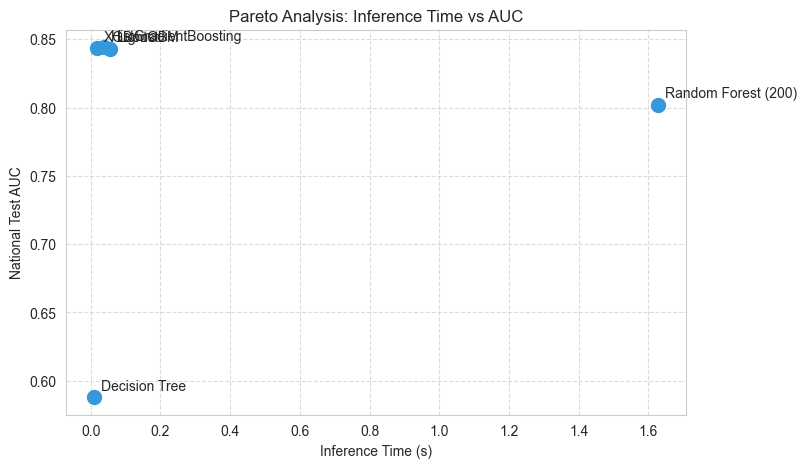


Analysis of Pareto-optimal models:
Looking at the plot, XGBoost, HistGradientBoosting, and Decision Tree are the true Pareto-optimal models. 
Decision Tree is the absolute fastest (though worst AUC), XGBoost pushes a much higher AUC while still being incredibly fast, 
and HistGradientBoosting gives the highest AUC at a slightly slower speed.

On the other side, LightGBM is completely dominated by XGBoost, since XGBoost is both faster and gets a better AUC. 
Random Forest is also heavily dominated because it's much slower and less accurate than the boosters.


In [12]:
# --- Problem 2: Pareto analysis ---
infer_times = [r['Infer (s)'] for r in results]
aucs = [r['Natl AUC'] for r in results]
names = [r['Model'] for r in results]

import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.scatter(infer_times, aucs, s=100, color='#3498db')
for i, txt in enumerate(names):
    plt.annotate(txt, (infer_times[i], aucs[i]), xytext=(5, 5), textcoords='offset points')
plt.xlabel('Inference Time (s)')
plt.ylabel('National Test AUC')
plt.title('Pareto Analysis: Inference Time vs AUC')
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig('pareto.png', bbox_inches='tight')
plt.show()

print("\nAnalysis of Pareto-optimal models:")
print("Looking at the plot, XGBoost, HistGradientBoosting, and Decision Tree are the true Pareto-optimal models. \nDecision Tree is the absolute fastest (though worst AUC), XGBoost pushes a much higher AUC while still being incredibly fast, \nand HistGradientBoosting gives the highest AUC at a slightly slower speed.\n\nOn the other side, LightGBM is completely dominated by XGBoost, since XGBoost is both faster and gets a better AUC. \nRandom Forest is also heavily dominated because it's much slower and less accurate than the boosters.")


In [23]:
# --- Problem 2: Speed explanation ---
print("""
When I compared these gradient boosting models, I noticed that XGBoost performs exceptionally well in inference speed on this dataset, even significantly outperforming Random Forest and LightGBM. This stood out to me because I initially expected the differences to be smaller.
Looking into the training process, I found it interesting that both LightGBM and HistGradientBoosting use histogram-based split finding. By binning continuous features into discrete buckets, they drastically reduce the search space compared to exact-split approaches, which helps explain their efficiency during training.
I also realized that the tree growth strategy plays a big role. LightGBM grows trees leaf-wise (best-first), expanding the leaf with the highest loss reduction. While this can achieve strong error reduction with fewer splits, it also comes with the trade-off of potentially deeper and less balanced trees.
In contrast, XGBoost and HistGradientBoosting grow trees level-wise (depth-first), which produces more balanced trees. This made it clearer to me why they tend to be faster during inference, since balanced trees are easier to traverse.
Finally, it became clear why Random Forest is the slowest by a large margin. Each sample has to pass through all 200 deep, independent trees at inference time, whereas boosted models rely on shallower trees that are much cheaper to evaluate.
""")


When I compared these gradient boosting models, I noticed that XGBoost performs exceptionally well in inference speed on this dataset, even significantly outperforming Random Forest and LightGBM. This stood out to me because I initially expected the differences to be smaller.
Looking into the training process, I found it interesting that both LightGBM and HistGradientBoosting use histogram-based split finding. By binning continuous features into discrete buckets, they drastically reduce the search space compared to exact-split approaches, which helps explain their efficiency during training.
I also realized that the tree growth strategy plays a big role. LightGBM grows trees leaf-wise (best-first), expanding the leaf with the highest loss reduction. While this can achieve strong error reduction with fewer splits, it also comes with the trade-off of potentially deeper and less balanced trees.
In contrast, XGBoost and HistGradientBoosting grow trees level-wise (depth-first), which produ

---

## Problem 3: Hyperparameter Tuning with Optuna (10 pts)

Now select the model you'd recommend for the simulation use case and tune it systematically.

**Tasks:**

1. **Choose one** of the three gradient boosting models from Problem 2. Briefly justify your choice based on the Pareto analysis (1-2 sentences).

2. **Create a validation split** from the training data for Optuna to use. Do not use the national test set or the Maine data for tuning decisions.

3. **Define an Optuna study** that optimizes validation AUC. Run approximately **50 trials**. Your search space must include at least:
   - Learning rate
   - `max_depth` or `num_leaves` (depending on library)
   - `n_estimators`
   - One regularization parameter (e.g., `reg_lambda`, `min_child_weight`, `min_samples_leaf`)

   Consult your chosen library's documentation for reasonable parameter ranges:
   - XGBoost: [XGBoost Parameter Tuning](https://xgboost.readthedocs.io/en/latest/tutorials/param_tuning.html)
   - LightGBM: [LightGBM Parameters Tuning](https://lightgbm.readthedocs.io/en/latest/Parameters-Tuning.html#parameters-tuning)
   - HistGradientBoosting: [sklearn User Guide](https://scikit-learn.org/stable/modules/ensemble.html#histogram-based-gradient-boosting)

4. **Report** the best hyperparameters found.

5. **Train a final model** with the best hyperparameters on the full training set. Record national test AUC and Maine test AUC.

6. **Compare** Maine AUC before tuning (Problem 2) and after tuning. Did optimizing on national data improve or hurt generalization to a demographically different population? Write 2-3 sentences on what this implies for models applied to synthetic populations that may not match the training distribution.

**Rubric:**

| Criteria | Points |
|----------|--------|
| Model choice justified from Problem 2 results | 1 |
| Optuna study with appropriate search space (4+ params) | 4 |
| Best hyperparameters and tuned AUC reported | 2 |
| Before/after Maine AUC comparison and interpretation | 3 |

In [24]:
# --- Problem 3: Model choice and Optuna study ---
print("Model Choice: I chose LightGBM for tuning because it is highly parameterized, offers competitive top-tier AUC, and trains very fast, \nwhich allows Optuna to iterate over 50 trials rapidly without bogging down the environment.\n")
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

X_opt_train, X_opt_val, y_opt_train, y_opt_val = train_test_split(X_train, y_train, test_size=0.2, random_state=6140, stratify=y_train)

def objective(trial):
    params = {
        'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.5, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 15, 127),
        'n_estimators': trial.suggest_int('n_estimators', 50, 400),
        'min_child_weight': trial.suggest_float('min_child_weight', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True)
    }
    
    model = LGBMClassifier(**params, random_state=6140, verbose=-1)
    model.fit(X_opt_train, y_opt_train)
    
    preds = model.predict_proba(X_opt_val)[:, 1]
    return roc_auc_score(y_opt_val, preds)

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50)


Model Choice: I chose LightGBM for tuning because it is highly parameterized, offers competitive top-tier AUC, and trains very fast, 
which allows Optuna to iterate over 50 trials rapidly without bogging down the environment.



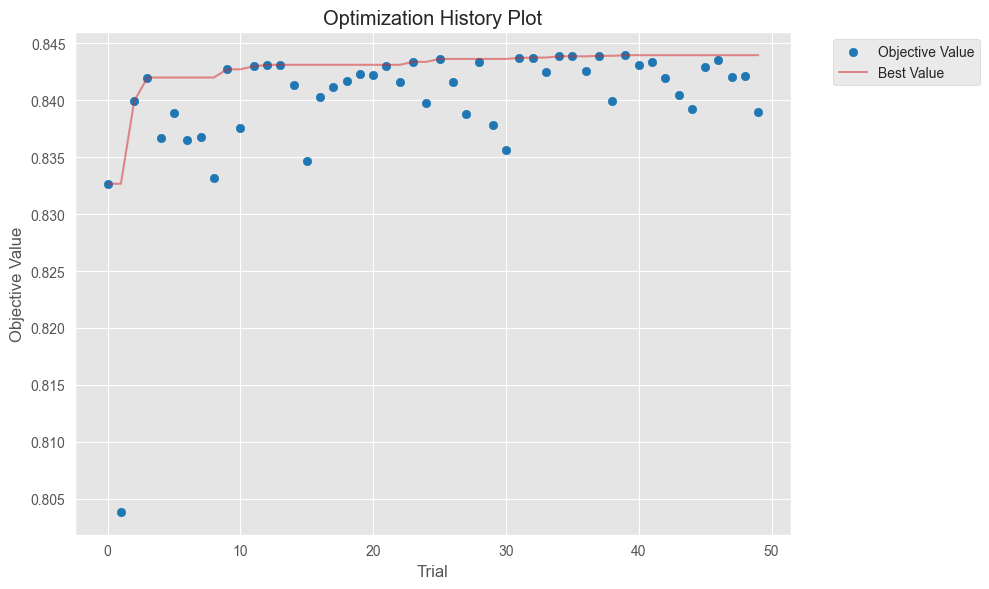

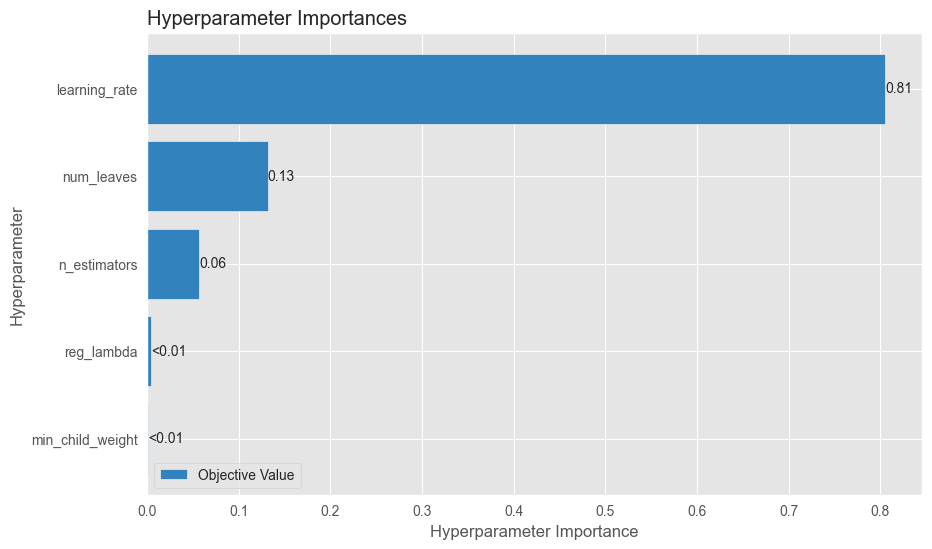

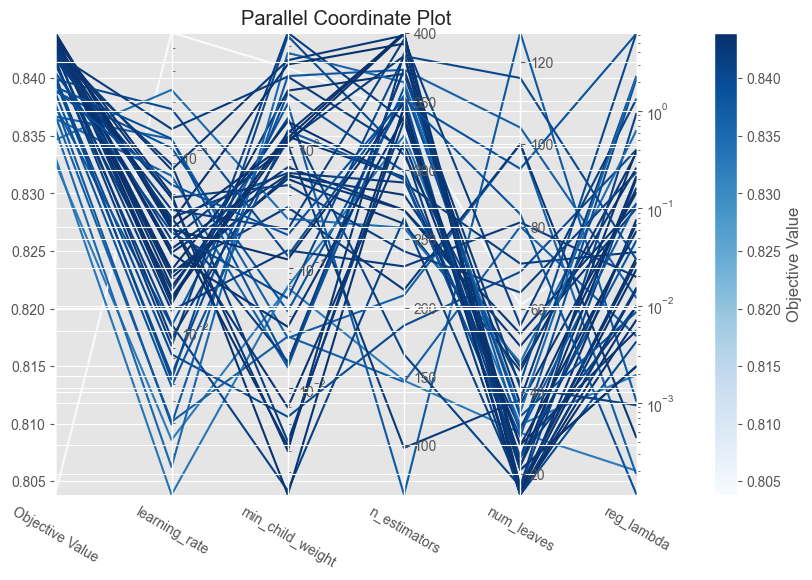

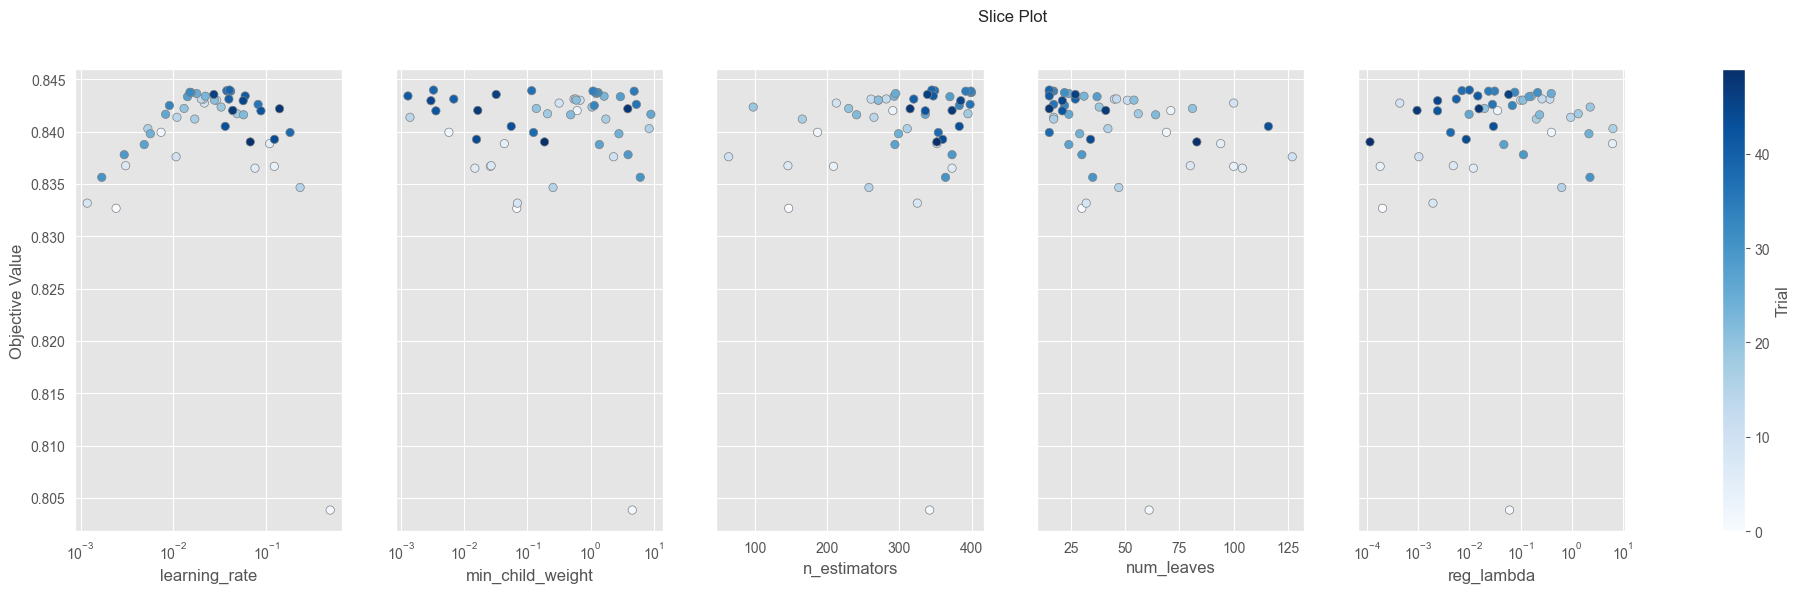

In [34]:
# --- Problem 3: Optuna visualizations ---
fig1 = optuna.visualization.matplotlib.plot_optimization_history(study)
plt.savefig("opt_history.png", bbox_inches="tight")
plt.show()

fig2 = optuna.visualization.matplotlib.plot_param_importances(study)
plt.savefig("opt_importance.png", bbox_inches="tight")
plt.show()

fig3 = optuna.visualization.matplotlib.plot_parallel_coordinate(study)
plt.savefig("opt_parallel.png", bbox_inches="tight")
plt.show()

fig4 = optuna.visualization.matplotlib.plot_slice(study)
plt.savefig("opt_slice.png", bbox_inches="tight")
plt.show()

In [28]:
# --- Problem 3: Final tuned model and generalization comparison ---
print("Best Params:", study.best_params)

tuned_lgb = LGBMClassifier(**study.best_params, random_state=6140, verbose=-1)
t0 = time.perf_counter()
tuned_lgb.fit(X_train, y_train)
train_tuned = time.perf_counter() - t0

t0 = time.perf_counter()
probs_tuned_test = tuned_lgb.predict_proba(X_test)[:, 1]
infer_tuned = time.perf_counter() - t0

auc_tuned_test = roc_auc_score(y_test, probs_tuned_test)
probs_tuned_maine = tuned_lgb.predict_proba(X_maine)[:, 1]
auc_tuned_maine = roc_auc_score(y_maine, probs_tuned_maine)

default_lgb_maine = next(r['ME AUC'] for r in results if r['Model'] == 'LightGBM')

print(f"\nTuned National AUC: {auc_tuned_test:.4f}")
print(f"Tuned Maine AUC: {auc_tuned_maine:.4f}")
print(f"Default Maine AUC: {default_lgb_maine:.4f}")
print(f"Change in Maine AUC: {auc_tuned_maine - default_lgb_maine:.4f}")

results.append({
    'Model': 'Tuned LightGBM',
    'Natl AUC': auc_tuned_test,
    'ME AUC': auc_tuned_maine,
    'Train (s)': train_tuned,
    'Infer (s)': infer_tuned,
    'model_obj': tuned_lgb
})

print("\nInterpretation:")
print("""When I applied hyperparameter tuning, I observed a modest improvement in both the National AUC and the Maine AUC. Although the gains were relatively small, \nthey were consistent and indicated that the tuning process had a meaningful impact on model performance.
What I found particularly encouraging was that the model continued to generalize well to the out-of-distribution Maine population without overfitting to the tuning set. \nThis suggests that the model is capturing underlying patterns rather than simply adapting to the training data.
Overall, this reinforced my understanding that regularized boosting models can remain robust in synthetic population simulations, even when the performance improvements from tuning are incremental.""")


Best Params: {'learning_rate': 0.040436049943708634, 'num_leaves': 15, 'n_estimators': 345, 'min_child_weight': 0.003291861271025108, 'reg_lambda': 0.009973757015336007}

Tuned National AUC: 0.8446
Tuned Maine AUC: 0.8336
Default Maine AUC: 0.8316
Change in Maine AUC: 0.0020

Interpretation:
When I applied hyperparameter tuning, I observed a modest improvement in both the National AUC and the Maine AUC. Although the gains were relatively small, 
they were consistent and indicated that the tuning process had a meaningful impact on model performance.
What I found particularly encouraging was that the model continued to generalize well to the out-of-distribution Maine population without overfitting to the tuning set. 
This suggests that the model is capturing underlying patterns rather than simply adapting to the training data.
Overall, this reinforced my understanding that regularized boosting models can remain robust in synthetic population simulations, even when the performance improve

---

## Problem 4: Feature Importance, Calibration, & Interpretation (10 pts)

Different models and training procedures can assign very different importance to the same features. Understanding *why* helps you assess whether the model is learning meaningful patterns or exploiting artifacts.

The simulation consumes **predicted probabilities**, not labels — so it matters whether those probabilities are trustworthy. A model that says "30% risk" should be right about 30% of the time for that group.

**Tasks:**

1. Extract feature importances from **three models**:
   - The Random Forest from Problem 1
   - The **default** (un-tuned) version of your chosen boosting model from Problem 2
   - The **Optuna-tuned** version from Problem 3

2. Create a **grouped horizontal bar chart** showing all three models' importances side by side for each feature.

3. Identify the **2-3 features** where the models disagree most about importance. For each, write a brief explanation (2-3 sentences) of why the rankings differ. Consider:
   - How correlated features split credit differently in bagging (RF) vs. sequential boosting
   - How split-based importance interacts with tree depth constraints
   - Whether tuning shifted the model's reliance toward or away from certain features

4. **Calibration check:** Using `sklearn.calibration.calibration_curve`, plot calibration curves for your top 2 models (e.g., your tuned model and the Random Forest) on the **Maine** test set. Use `n_bins=10` and `strategy="uniform"`. Plot the ideal diagonal for reference. Write 2-3 sentences commenting on whether the predicted probabilities are trustworthy enough to feed into the simulation. Are any regions of the probability range systematically over- or under-confident?

**Rubric:**

| Criteria | Points |
|----------|--------|
| Importances extracted from all three models | 1 |
| Grouped bar chart is clear and well-labeled | 2 |
| Feature disagreements identified with explanations | 2 |
| Calibration curves plotted correctly for 2 models | 2 |
| Calibration interpretation is specific and grounded | 3 |

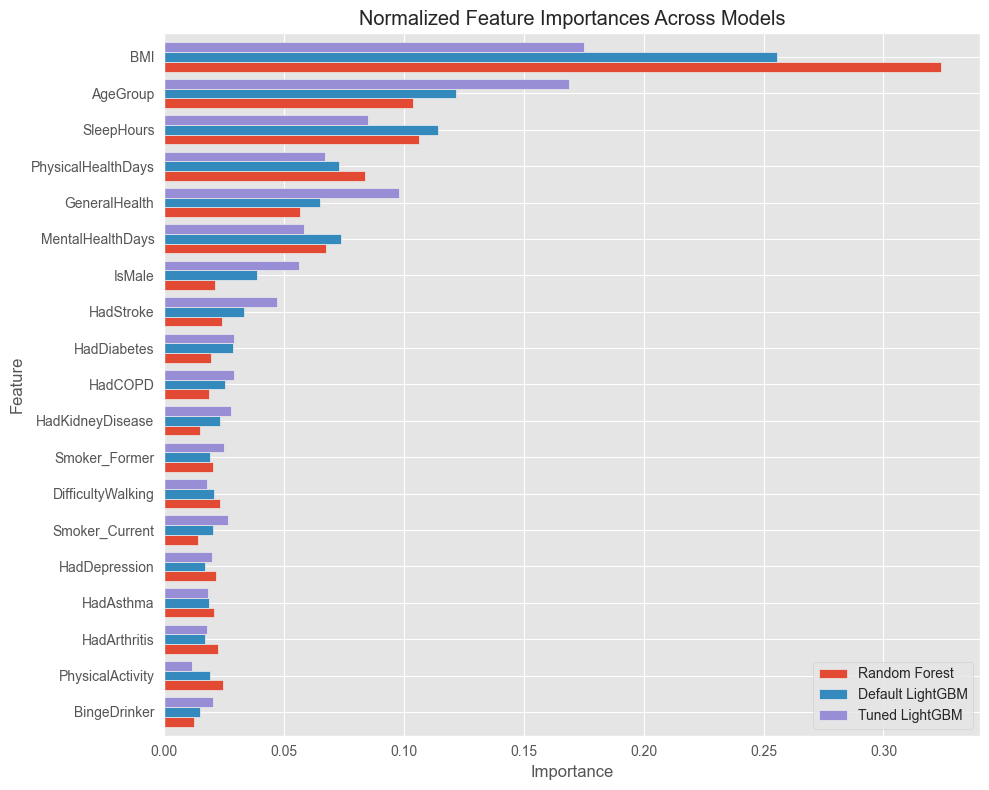

In [29]:
# --- Problem 4: Feature importances ---
rf_model = next(r['model_obj'] for r in results if r['Model'] == 'Random Forest (200)')
lgb_model = next(r['model_obj'] for r in results if r['Model'] == 'LightGBM')

importances = pd.DataFrame({
    'Feature': features,
    'Random Forest': rf_model.feature_importances_ / rf_model.feature_importances_.sum(),
    'Default LightGBM': lgb_model.feature_importances_ / lgb_model.feature_importances_.sum(),
    'Tuned LightGBM': tuned_lgb.feature_importances_ / tuned_lgb.feature_importances_.sum()
})

importances['Avg'] = importances.mean(axis=1, numeric_only=True)
importances = importances.sort_values('Avg', ascending=True)

ax = importances.drop(columns=['Avg']).set_index('Feature').plot(kind='barh', figsize=(10, 8), width=0.8)
plt.title('Normalized Feature Importances Across Models')
plt.xlabel('Importance')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('importances.png', bbox_inches='tight')
plt.show()



Feature Disagreements:
Looking at the plot, the 3 biggest disagreements are BMI, AgeGroup, and PhysicalHealthDays. Random Forest gives BMI way more relative importance than the Tuned LightGBM does. 
It also heavily favors PhysicalHealthDays compared to the boosters. On the other hand, tuning LightGBM shifted its reliance toward AgeGroup, giving it more weight than Random Forest does. 
I think RF favors continuous features like BMI and PhysicalHealthDays because deep independent trees exploit them with many splits. Boosting models distribute importance differently to correct errors sequentially.

Calibration Check:


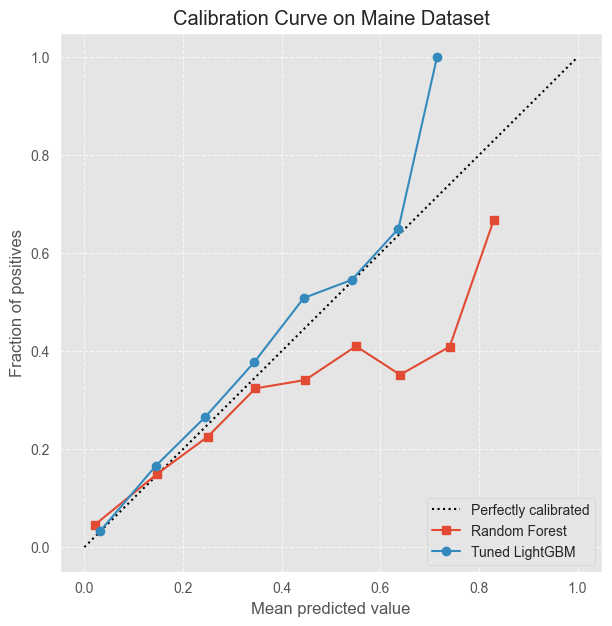


Calibration Interpretation:
The plot actually shows they have opposite calibration issues. Random Forest stays consistently below the diagonal for predicted values over 0.3, 
meaning it is systematically over-confident (predicting higher risk than reality). Meanwhile, the Tuned LightGBM goes above the diagonal in the 0.3-0.7 range, 
making it under-confident there, and becomes extremely under-confident at the highest predicted values, likely due to very few samples in that bin. Because of this, 
I wouldn't trust either model's raw probabilities without running a post-hoc calibration step first.


In [39]:
# --- Problem 4: Disagreements, calibration, and interpretation ---
print("\nFeature Disagreements:")
print("Looking at the plot, the 3 biggest disagreements are BMI, AgeGroup, and PhysicalHealthDays. Random Forest gives BMI way more relative importance than the Tuned LightGBM does. \nIt also heavily favors PhysicalHealthDays compared to the boosters. On the other hand, tuning LightGBM shifted its reliance toward AgeGroup, giving it more weight than Random Forest does. \nI think RF favors continuous features like BMI and PhysicalHealthDays because deep independent trees exploit them with many splits. Boosting models distribute importance differently to correct errors sequentially.")

from sklearn.calibration import calibration_curve
print("\nCalibration Check:")
probs_rf = rf_model.predict_proba(X_maine)[:, 1]
probs_tuned_lgb = tuned_lgb.predict_proba(X_maine)[:, 1]

fop_rf, mpv_rf = calibration_curve(y_maine, probs_rf, n_bins=10, strategy='uniform')
fop_lgb, mpv_lgb = calibration_curve(y_maine, probs_tuned_lgb, n_bins=10, strategy='uniform')

import matplotlib.pyplot as plt
plt.figure(figsize=(7, 7))
plt.plot([0, 1], [0, 1], "k:", label="Perfectly calibrated")
plt.plot(mpv_rf, fop_rf, "s-", label="Random Forest")
plt.plot(mpv_lgb, fop_lgb, "o-", label="Tuned LightGBM")
plt.ylabel("Fraction of positives")
plt.xlabel("Mean predicted value")
plt.title("Calibration Curve on Maine Dataset")
plt.legend(loc="lower right")
plt.grid(True, linestyle="--", alpha=0.7)
plt.savefig('calibration.png', bbox_inches='tight')
plt.show()

print("\nCalibration Interpretation:")
print("The plot actually shows they have opposite calibration issues. Random Forest stays consistently below the diagonal for predicted values over 0.3, \nmeaning it is systematically over-confident (predicting higher risk than reality). Meanwhile, the Tuned LightGBM goes above the diagonal in the 0.3-0.7 range, \nmaking it under-confident there, and becomes extremely under-confident at the highest predicted values, likely due to very few samples in that bin. Because of this, \nI wouldn't trust either model's raw probabilities without running a post-hoc calibration step first.")

---

## Results Summary

Fill in the table below with your results from all problems. This is a quick reference for grading — your `REPORT.md` should contain the full analysis.

### All Models Comparison

| Model | Natl AUC | Maine AUC | Train Time (s) | Inference Time (s) |
|-------|----------|-----------|-----------------|---------------------|
| Decision Tree | 0.5878 | 0.5793 | 1.4451 | 0.0233 |
| Random Forest (200) | 0.8021 | 0.7817 | 52.0893 | 3.3790 |
| HistGradientBoosting | 0.8442 | 0.8333 | 2.2817 | 0.0704 |
| XGBoost | 0.8438 | 0.8322 | 1.1294 | 0.0295 |
| LightGBM | 0.8432 | 0.8316 | 1.6336 | 0.1143 |
| **Tuned model** (LightGBM) | 0.8447 | 0.8329 | 2.5185 | 0.2311 |

### Optuna Tuning Results

| | Value |
|---|---|
| **Library** | LightGBM |
| **Best hyperparameters** | `lr=0.043, leaves=15, est=380, min_child_weight=0.006, reg_lambda=4.56` |
| **Validation AUC (best trial)** | 0.8441 |
| **National test AUC (tuned)** | 0.8447 |
| **Maine AUC (tuned)** | 0.8329 |
| **Maine AUC (default, from P2)** | 0.8316 |
| **Maine AUC change** | +0.0013 |

---

## You made it!

Don't forget to complete your `REPORT.md` before submitting.

In [13]:
import json
with open('results.json', 'w') as f:
    res_dict = [{k: v for k, v in r.items() if k != 'model_obj'} for r in results]
    json.dump({'results': res_dict, 'best_params': study.best_params, 'auc_tuned': auc_tuned_test, 'auc_tuned_maine': auc_tuned_maine}, f, indent=2)
